In [34]:
#1.1 Import pandas
import pandas as pd

loan = pd.read_csv('loans.csv')
loan['Signature Date'] = pd.to_datetime(loan['Signature Date'])

In [35]:
#1.2 Load & Clean Data
loan['Signed Amount'] = pd.to_numeric(loan['Signed Amount'], errors='coerce')
loan['Signature Date'] = pd.to_datetime(loan['Signature Date'], errors='coerce')
loan = loan[loan['Signature Date'].dt.year >= 1980]

In [36]:
#1.3 Check if any duplicates exist using the any() function (https://www.w3schools.com/python/ref_func_any.asp)
print(f"Any duplicates? {loan.duplicated().any()}")

#1.4 Count total duplicates
print(f"Number of duplicate rows: {loan.duplicated().sum()}")

Any duplicates? True
Number of duplicate rows: 894


In [37]:
#1.4 View the duplicate rows
loan[loan.duplicated(keep=False)]  # keep=False shows ALL copies of the duplicates

,Name,Region,Country or Territory,Sector,Signature Date,Signed Amount,Description,signed_num,median_signed,High_Signed_Amount
231,AFFORDABLE HOUSING ERSTE BANK III,European Union,Austria,Urban development,2024-06-24,75000000.0,The operation is aimed at supporting the const...,75000000.0,26178285,1
232,AFFORDABLE HOUSING ERSTE BANK III,European Union,Austria,Urban development,2024-06-24,75000000.0,The operation is aimed at supporting the const...,75000000.0,26178285,1
250,ALGEA (EGFF),European Union,Austria,Services,2019-02-25,7500000.0,The Company is a biopharmaceutical company dev...,7500000.0,26178285,0
251,ALGEA (EGFF),European Union,Austria,Services,2019-02-25,7500000.0,The Company is a biopharmaceutical company dev...,7500000.0,26178285,0
266,AUSTRIAN AIRLINES II,European Union,Austria,Transport,2000-06-30,13226141.0,Acquisition of 3 Airbus A-320 aircraft to rene...,13226141.0,26178285,0
...,...,...,...,...,...,...,...,...,...,...
27265,UK POWER NETWORKS UPGRADE,United Kingdom,United Kingdom,Energy,2012-12-19,98667982.0,The project is a 3-year investment programme a...,98667982.0,26178285,1
27411,MONTEVIDEO CONTAINER TERMINAL,Asia and Latin America,Uruguay,Transport,2007-12-07,5379000.0,Expansion of a private container terminal at M...,5379000.0,26178285,0
27412,MONTEVIDEO CONTAINER TERMINAL,Asia and Latin America,Uruguay,Transport,2007-12-07,5379000.0,Expansion of a private container terminal at M...,5379000.0,26178285,0
27420,BAUERFIELD AIRPORT,"Africa, Caribbean, Pacific countries + OCT",Vanuatu,Transport,1999-09-23,1000000.0,Coordination avec CFD (Lomé III + IV),1000000.0,26178285,0


In [38]:
#1.5 Remove duplicates (keeps first occurrence)
loan = loan.drop_duplicates()

print(f"Duplicates removed!")
print(f"Rows remaining: {len(loan)}")

Duplicates removed!
Rows remaining: 25472


In [39]:
#2 Feature Engineering
#2.1 Region Binary
loan['Region_Binary'] = loan['Region'].map({'European Union': 1}).fillna(0).astype(int)

In [40]:
#2.2 High Signed Amount (target)
median_signed = loan['Signed Amount'].median()
loan['High Signed Amount'] = (loan['Signed Amount'] > median_signed).astype(int)

In [41]:
#2.3 Year
loan['Year'] = loan['Signature Date'].dt.year

In [42]:
#2.4 Bins (Signed Amount Group)
bins = [0, 10e6, 30e6, 80e6, 300e6, float('inf')]
labels = ['0–10M', '10–30M', '30–80M', '80–300M', '300M+']
loan['Signed Amount Group'] = pd.cut(loan['Signed Amount'], bins=bins, labels=labels)

In [43]:
#3.1 Descriptive Statistics
loan.describe()

,Signature Date,Signed Amount,signed_num,median_signed,High_Signed_Amount,Region_Binary,High Signed Amount,Year
count,25472,2.547200e+04,2.547200e+04,25472.0,25472.000000,25472.000000,25472.00000,25472.000000
mean,2006-03-18 21:56:52.311557888,6.562586e+07,6.562586e+07,26178285.0,0.527128,0.787217,0.48622,2005.592926
min,1980-01-04 00:00:00,0.000000e+00,0.000000e+00,26178285.0,0.000000,0.000000,0.00000,1980.000000
25%,1994-11-23 00:00:00,1.000000e+07,1.000000e+07,26178285.0,0.000000,1.000000,0.00000,1994.000000
50%,2007-12-05 12:00:00,3.000000e+07,3.000000e+07,26178285.0,1.000000,1.000000,0.00000,2007.000000
75%,2017-08-03 00:00:00,7.800000e+07,7.800000e+07,26178285.0,1.000000,1.000000,1.00000,2017.000000
max,2025-11-28 00:00:00,1.912655e+09,1.912655e+09,26178285.0,1.000000,1.000000,1.00000,2025.000000
std,NaN,9.891835e+07,9.891835e+07,0.0,0.499273,0.409283,0.49982,12.921066


In [44]:
#3.2 Top 5 regions by total signed amount
top_regions = (loan.groupby('Region')['signed_num'].sum().sort_values(ascending=False).head(5))
top_regions

,signed_num
Region,
European Union,1.400125e+12
United Kingdom,1.081450e+11
Enlargement Countries,5.202390e+10
Mediterranean countries,4.156860e+10
"Africa, Caribbean, Pacific countries + OCT",2.788854e+10


In [45]:
#3.3 Region percentages
region_pct = loan['Region'].value_counts(normalize=True) * 100
region_pct.round(2)

,proportion
Region,
European Union,78.72
"Africa, Caribbean, Pacific countries + OCT",7.15
United Kingdom,4.80
Mediterranean countries,3.17
Enlargement Countries,3.16
Asia and Latin America,1.77
"Eastern Europe, Southern Caucasus",0.63
EFTA countries,0.36
South Africa,0.24


In [46]:
#3.4 Sector totals (sum of signed amounts per sector)
sector_totals = (loan.groupby('Sector')['signed_num'].sum().sort_values(ascending=False))
sector_totals


,signed_num
Sector,
Credit lines,4.631955e+11
Transport,3.597337e+11
Energy,2.576842e+11
Industry,1.676950e+11
"Water, sewerage",8.510785e+10
Telecom,7.639876e+10
Services,6.523193e+10
Urban development,6.352936e+10
Education,5.181089e+10


3.5 Time trends

In [47]:
#3.5.1 Mean signed amount per year
mean_by_year = (loan.groupby('Year')['signed_num'].mean().sort_index())
mean_by_year


,signed_num
Year,
1980,1.495762e+07
1981,1.534889e+07
1982,1.788352e+07
1983,1.883257e+07
1984,1.895057e+07
1985,1.755218e+07
1986,1.734889e+07
1987,1.359121e+07
1988,1.672760e+07


In [48]:
#3.5.2 Median signed amount per year
median_by_year = (loan.groupby('Year')['signed_num'].median().sort_index())
median_by_year


,signed_num
Year,
1980,8500117.0
1981,9219191.5
1982,10901724.0
1983,13577733.0
1984,12992077.0
1985,10940121.0
1986,9000000.0
1987,7266576.5
1988,7956205.5


In [49]:
#3.5.3 Count of projects per year
count_by_year = (loan.groupby('Year')['signed_num'].count().sort_index())
count_by_year

,signed_num
Year,
1980,231
1981,226
1982,256
1983,299
1984,355
1985,383
1986,424
1987,548
1988,584


4 Visualisations

In [50]:
#4.1 Import matplotlib
import matplotlib.pyplot as plt

Text(0, 0.5, 'Average Signed Amount (€)')

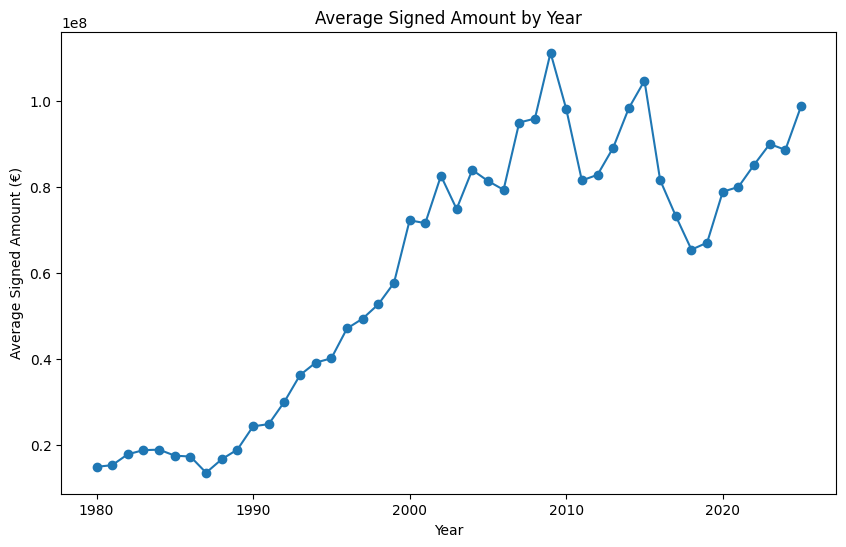

In [51]:
#4.2 Average Signed Amount by Year
avg_by_year = (loan.groupby('Year')['Signed Amount'].mean().sort_index())
plt.figure(figsize=(10, 6))
avg_by_year.plot(marker='o')
plt.title('Average Signed Amount by Year')
plt.xlabel('Year')
plt.ylabel('Average Signed Amount (€)')

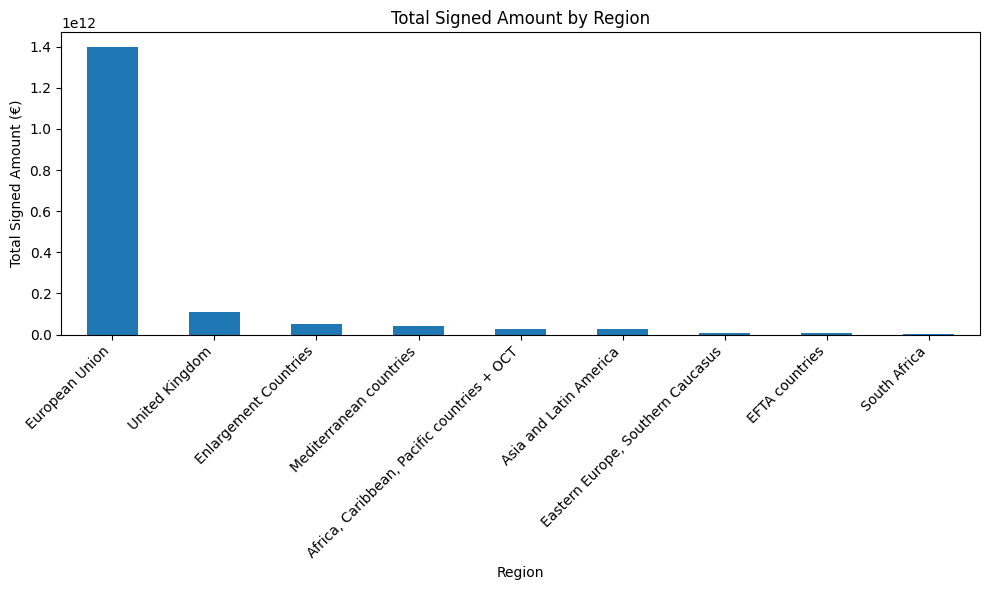

In [52]:
#4.3 Total Funding by Region
total_by_region = (loan.groupby('Region')['Signed Amount'].sum().sort_values(ascending=False))
plt.figure(figsize=(10, 6))
total_by_region.plot(kind='bar')
plt.title('Total Signed Amount by Region')
plt.xlabel('Region')
plt.ylabel('Total Signed Amount (€)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()


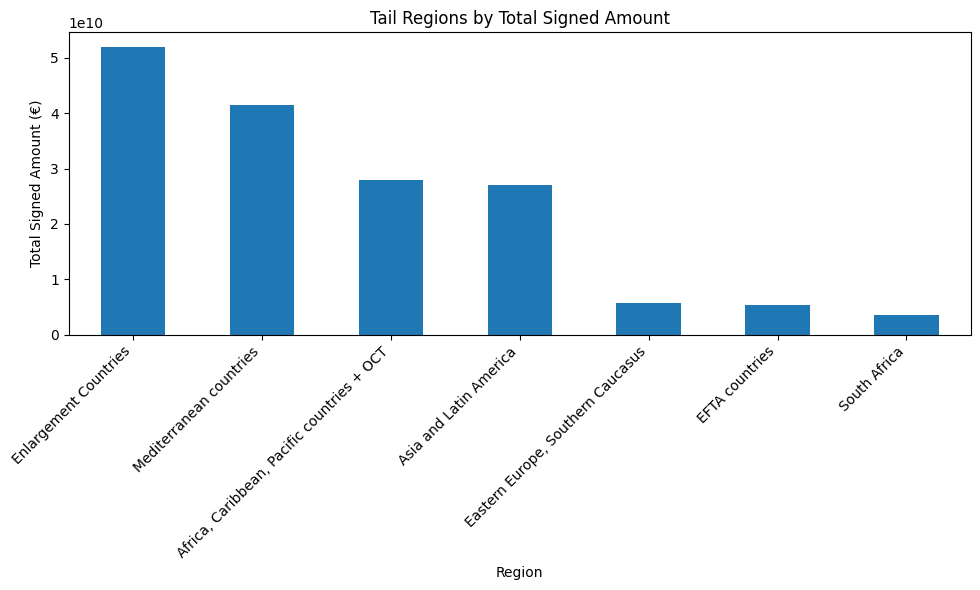

In [53]:
#4.3.1 Tail regions
total_by_region.tail(7).plot(kind='bar', figsize=(10,6))
plt.title('Tail Regions by Total Signed Amount')
plt.xlabel('Region')
plt.ylabel('Total Signed Amount (€)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

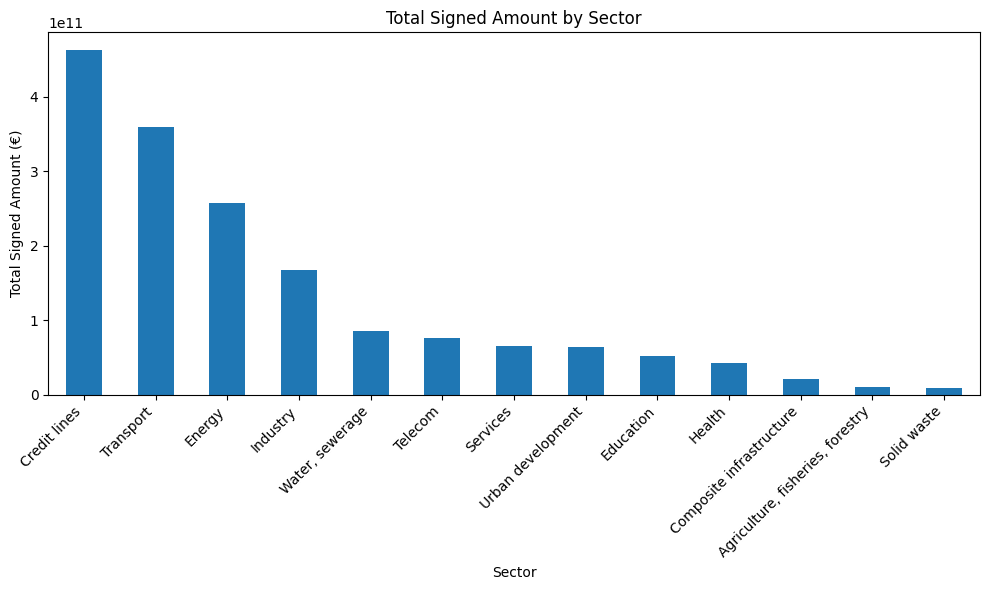

In [54]:
#4.4 Funding by Sector
total_by_sector = (loan.groupby('Sector')['Signed Amount'].sum().sort_values(ascending=False))
plt.figure(figsize=(10, 6))
total_by_sector.plot(kind='bar')
plt.title('Total Signed Amount by Sector')
plt.xlabel('Sector')
plt.ylabel('Total Signed Amount (€)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


4.5 EU vs Non-EU Funding Distribution

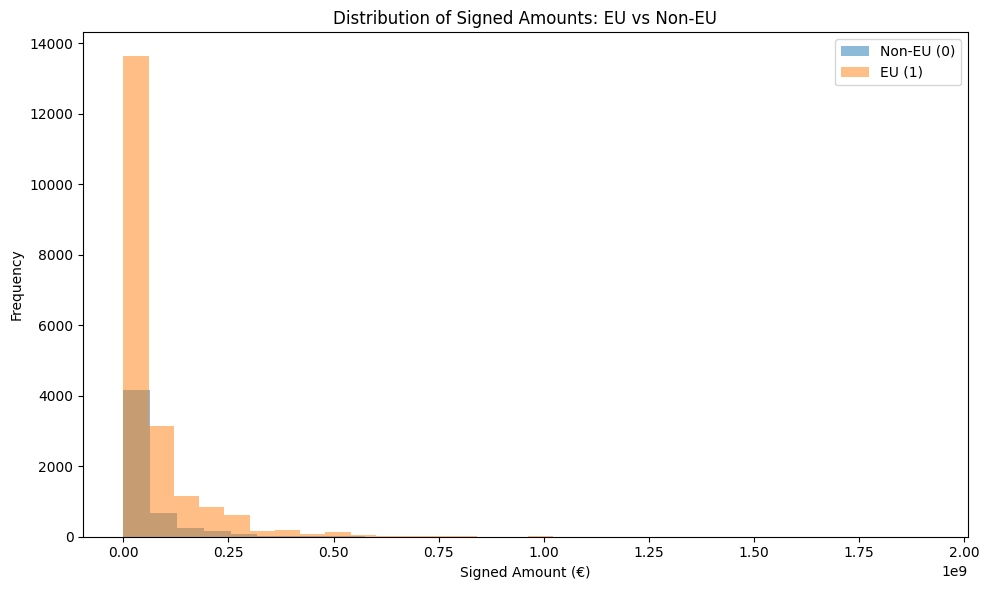

In [55]:
#4.5.1 Histogram
plt.figure(figsize=(10, 6))
loan[loan['Region_Binary'] == 0]['Signed Amount'].plot.hist(bins=30, alpha = 0.5, label='Non-EU (0)')
loan[loan['Region_Binary'] == 1]['Signed Amount'].plot.hist(bins=30, alpha = 0.5, label='EU (1)')
plt.title('Distribution of Signed Amounts: EU vs Non-EU')
plt.xlabel('Signed Amount (€)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()


<Figure size 800x600 with 0 Axes>

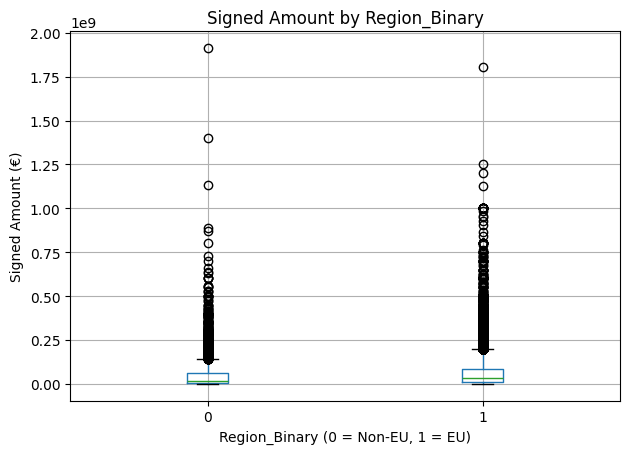

In [56]:
#5.5.2 Boxplot
plt.figure(figsize=(8, 6))
loan.boxplot(column='Signed Amount',by='Region_Binary')
plt.title('Signed Amount by Region_Binary')
plt.suptitle('')  #remove automatic pandas title
plt.xlabel('Region_Binary (0 = Non-EU, 1 = EU)')
plt.ylabel('Signed Amount (€)')
plt.tight_layout()


In [57]:
#5.5.3 import numpy as np
import numpy as np

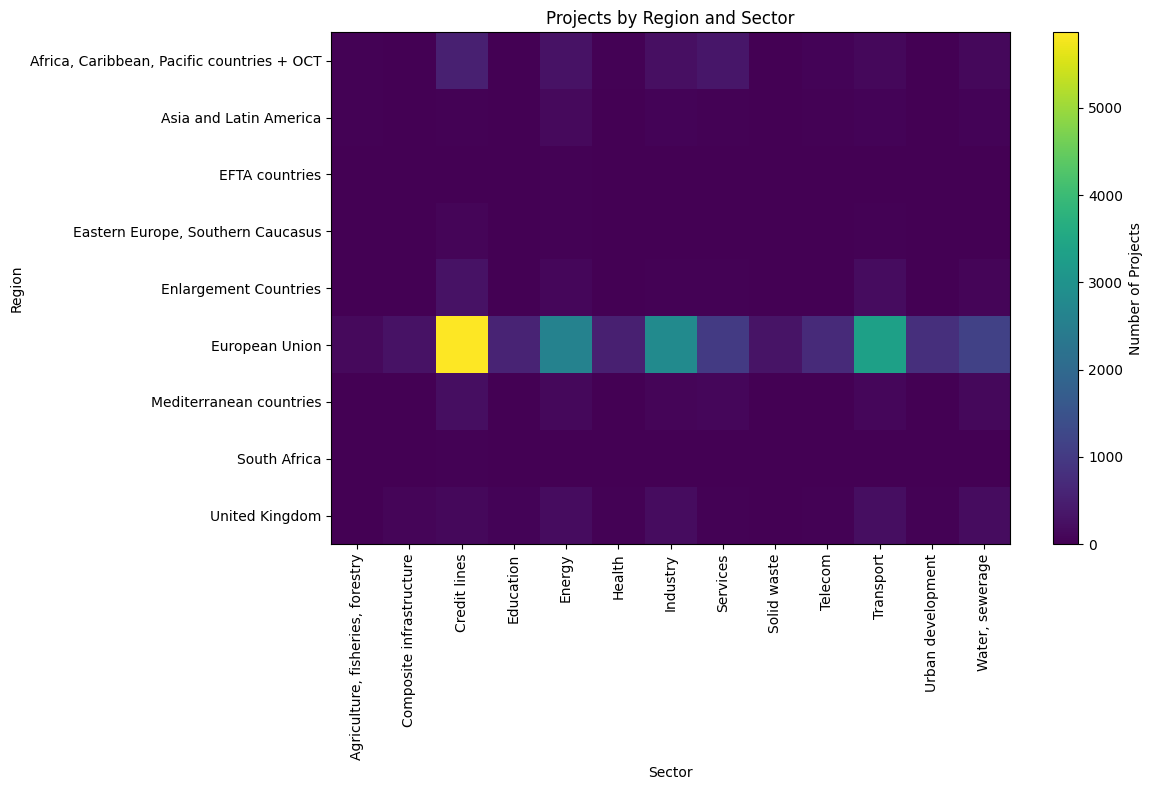

In [58]:
#5.5.4 Heatmap: Region x Sector
region_sector = pd.crosstab(loan['Region'], loan['Sector'])
plt.figure(figsize=(12, 8))
plt.imshow(region_sector, aspect='auto')
plt.colorbar(label='Number of Projects')
plt.title('Projects by Region and Sector')
plt.xlabel('Sector')
plt.ylabel('Region')
plt.xticks(ticks=np.arange(len(region_sector.columns)),labels=region_sector.columns,rotation=90)
plt.yticks(ticks=np.arange(len(region_sector.index)),labels=region_sector.index)
plt.tight_layout()

**6 ML COMPONENT**

**Problem:**

Predict whether a project is high-value (above median).

**Model:**

**Logistic Regression** — transparent + interpretable.

**Features:**
*   Region_Binary
*   Sector (one-hot)
*   Year

In [59]:
#6.1 Logistic regression
X = loan[['Region_Binary', 'Sector', 'Year']]
X = pd.get_dummies(X, drop_first=True)

y = loan['High Signed Amount']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Train logistic regression
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [60]:
#6.2 Evaluation
from sklearn.metrics import accuracy_score
print("Accuracy:", round(accuracy_score(y_test, y_pred), 2))

Accuracy: 0.65


In [61]:
#6.3 Feature importance
feature_importance = pd.Series(model.coef_[0],index=X.columns).sort_values(ascending=False)
round(feature_importance, 2)

,0
Sector_Telecom,1.48
Sector_Transport,1.31
Sector_Energy,0.93
Sector_Credit lines,0.84
Sector_Education,0.80
Sector_Health,0.71
Sector_Composite infrastructure,0.62
Sector_Urban development,0.59
"Sector_Water, sewerage",0.53
Region_Binary,0.51


<Axes: title={'center': 'Top Positive Predictors'}>

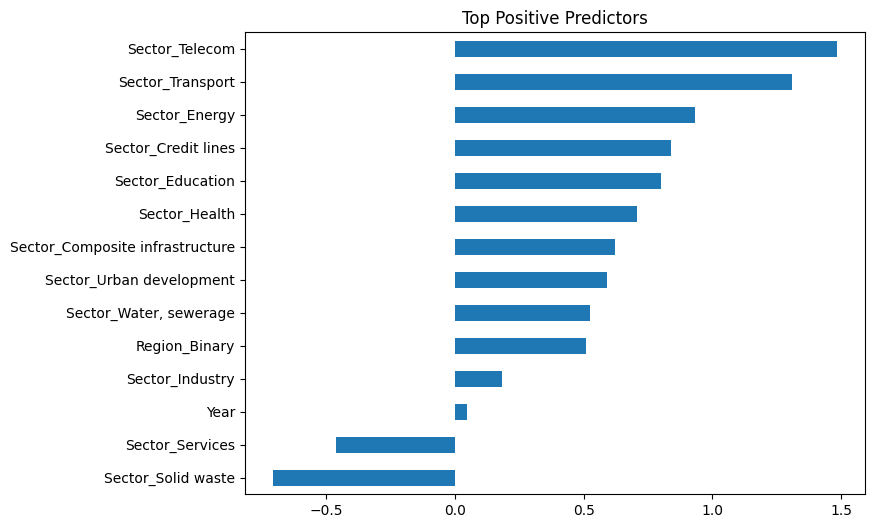

In [62]:
#6.4 plot
feature_importance.head(15).sort_values(ascending=True).plot(kind='barh', figsize=(8,6), title='Top Positive Predictors')

In [63]:
#7.1 Re-export the df
loan.to_csv('loan_cleaned.csv', index=False)

In [64]:
#7.2 Download the file
from google.colab import files
files.download('loan_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>